<a href="https://colab.research.google.com/github/bavucadoz/PemMes_2026/blob/main/Minggu04/TG4_244107020162_AryaBayuSamodra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tugas Praktikum**



---


##**1. Tugas K-Means**

**Langkah Awal:**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

  1. Gunakan data 'Mall_Customers.csv'

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [4]:
df_mall = pd.read_csv('Mall_Customers.csv')

  2. Tentukan fitur apa yang tepat untuk melakukan clustering (minimal 2)

In [5]:
X = df_mall[['Annual Income (k$)', 'Spending Score (1-100)']]

  3. Buatlah model K-Means dengan mempertimbangkan jumlah *k* yang terbaik.

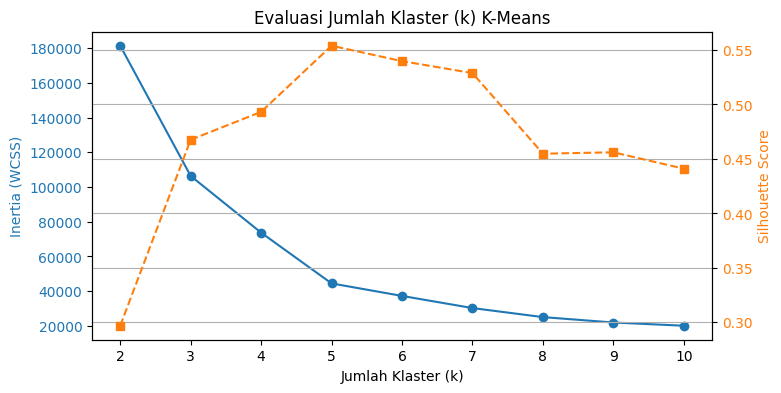

In [7]:
# Mencari nilai k terbaik (Elbow Method & Silhouette Score)
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))

# Visualisasi Elbow & Silhouette
fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.set_xlabel('Jumlah Klaster (k)')
ax1.set_ylabel('Inertia (WCSS)', color='tab:blue')
ax1.plot(K_range, inertias, marker='o', color='tab:blue', label='Inertia')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:orange')
ax2.plot(K_range, silhouette_scores, marker='s', color='tab:orange', linestyle='--', label='Silhouette')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title('Evaluasi Jumlah Klaster (k) K-Means')
plt.grid(True)
plt.show()

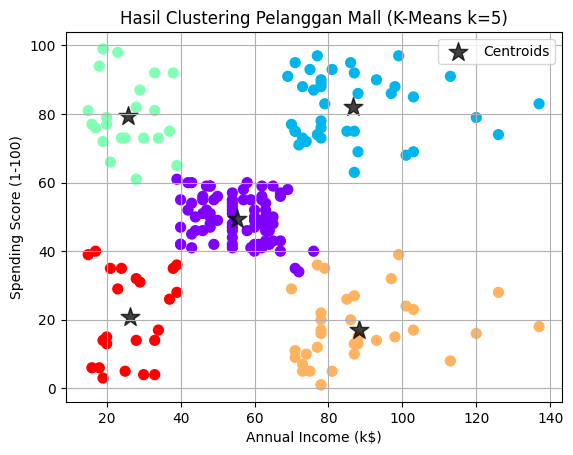

In [12]:
# Inisiasi obyek KMeans dengan k=5
cl_kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

y_kmeans = cl_kmeans.fit_predict(X)
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s=50, c=y_kmeans, cmap='rainbow')

centers = cl_kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, marker='*', alpha=0.75, label='Centroids')

plt.title('Hasil Clustering Pelanggan Mall (K-Means k=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()



---

## **2. Tugas DBSCAN**

**Langkah Awal:**

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn import metrics

  1. Buat dataset make_moons (1000 sampel, noise=0.05), lalu normalisasi.

In [30]:
X_moons, y_moons = make_moons(n_samples=1000, noise=0.05, random_state=42)
X_scaled = StandardScaler().fit_transform(X_moons)

  2. Jalankan DBSCAN dengan *eps=0.2, min_samples=5,* hitung jumlah klaster & noise.

In [31]:
db = DBSCAN(eps=0.2, min_samples=5).fit(X_scaled)
labels = db.labels_

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print(f"Jumlah Klaster: {n_clusters_}")
print(f"Jumlah Noise Points: {n_noise_}")

Jumlah Klaster: 2
Jumlah Noise Points: 0


  3. Evaluasi dengan metrik: Homogeneity, Completeness, V-measure, ARI, AMI, Silhouette.

In [32]:
print("\n=== METRIK EVALUASI BASELINE ===")
print(f"Homogeneity            : {metrics.homogeneity_score(y_moons, labels):.4f}")
print(f"Completeness           : {metrics.completeness_score(y_moons, labels):.4f}")
print(f"V-measure              : {metrics.v_measure_score(y_moons, labels):.4f}")
print(f"Adjusted Rand Index    : {metrics.adjusted_rand_score(y_moons, labels):.4f}")
print(f"Adjusted Mutual Info   : {metrics.adjusted_mutual_info_score(y_moons, labels):.4f}")
print(f"Silhouette Coefficient : {metrics.silhouette_score(X_scaled, labels):.4f}")


=== METRIK EVALUASI BASELINE ===
Homogeneity            : 1.0000
Completeness           : 1.0000
V-measure              : 1.0000
Adjusted Rand Index    : 1.0000
Adjusted Mutual Info   : 1.0000
Silhouette Coefficient : 0.3912


  4. Visualisasikan hasil DBSCAN (core sample = titik besar, non-core = titik kecil, noise = hitam).

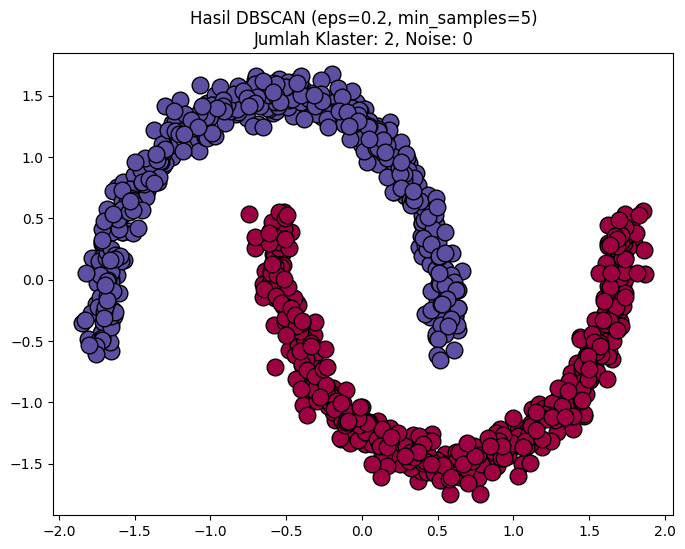

In [33]:
# Visualisasi Hasil DBSCAN
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

plt.figure(figsize=(8, 6))
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Warna hitam untuk noise
        col = [0, 0, 0, 1]

    class_member_mask = (labels == k)

    # Core samples (Titik Besar)
    xy = X_scaled[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col), markeredgecolor='k', markersize=12)

    # Non-core samples (Titik Kecil)
    xy = X_scaled[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col), markeredgecolor='k', markersize=5)

plt.title(f'Hasil DBSCAN (eps=0.2, min_samples=5)\nJumlah Klaster: {n_clusters_}, Noise: {n_noise_}')
plt.show()

  5. Lakukan eksperimen:

  - *eps = 0.05, 0.1, 0.3, 0.5*

  - *min_samples = 3, 10, 20*
  - Catat perubahan klaster, noise, dan kualitas evaluasi.

In [34]:
eps_list = [0.05, 0.10, 0.30, 0.50]
min_samples_list = [3, 10, 20]

results = []

for eps in eps_list:
    for ms in min_samples_list:
        db_exp = DBSCAN(eps=eps, min_samples=ms).fit(X_scaled)
        lbls = db_exp.labels_

        n_c = len(set(lbls)) - (1 if -1 in lbls else 0)
        n_n = list(lbls).count(-1)

        hom = metrics.homogeneity_score(y_moons, lbls)
        comp = metrics.completeness_score(y_moons, lbls)
        vm = metrics.v_measure_score(y_moons, lbls)
        ari = metrics.adjusted_rand_score(y_moons, lbls)
        ami = metrics.adjusted_mutual_info_score(y_moons, lbls)
        sil = metrics.silhouette_score(X_scaled, lbls) if n_c > 1 else np.nan

        results.append({
            'eps': eps,
            'min_samples': ms,
            'clusters': n_c,
            'noise': n_n,
            'homogeneity': round(hom, 4),
            'completeness': round(comp, 4),
            'v_measure': round(vm, 4),
            'ari': round(ari, 4),
            'ami': round(ami, 4),
            'silhouette': round(sil, 4) if not np.isnan(sil) else 'N/A'
        })

df_results = pd.DataFrame(results)
display(df_results)

,eps,min_samples,clusters,noise,homogeneity,completeness,v_measure,ari,ami,silhouette
0,0.05,3,69,186,0.8156,0.1525,0.2570,0.0300,0.2438,0.1129
1,0.05,10,3,970,0.0307,0.1268,0.0494,0.0023,0.0459,-0.2942
2,0.05,20,0,1000,0.0000,1.0000,0.0000,0.0000,0.0000,N/A
3,0.10,3,2,14,0.9862,0.9029,0.9427,0.9722,0.9426,0.2517
4,0.10,10,7,57,0.9433,0.4095,0.5711,0.5234,0.5698,0.1623
5,0.10,20,6,850,0.1539,0.1555,0.1547,0.0168,0.1509,-0.3602
6,0.30,3,2,0,1.0000,1.0000,1.0000,1.0000,1.0000,0.3912
7,0.30,10,2,0,1.0000,1.0000,1.0000,1.0000,1.0000,0.3912
8,0.30,20,2,0,1.0000,1.0000,1.0000,1.0000,1.0000,0.3912
9,0.50,3,2,0,1.0000,1.0000,1.0000,1.0000,1.0000,0.3912
